In [19]:
# ============================================================
# CELL 2: IMPORTS & CONFIGURATION
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from scipy.stats import norm
from scipy.optimize import brentq
from datetime import datetime, timedelta
import requests

warnings.filterwarnings("ignore")

# ── Output directory ──────────────────────────────────────────
os.makedirs("../outputs", exist_ok=True)

# ── Plot styling ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.6,
    "axes.grid":        True,
    "font.family":      "monospace",
    "figure.dpi":       130,
})

ACCENT   = "#58a6ff"   # blue
GREEN    = "#3fb950"   # call / long
RED      = "#f85149"   # put  / short
ORANGE   = "#d29922"   # neutral highlight
PURPLE   = "#bc8cff"

# ── Ticker to analyse ─────────────────────────────────────────
TICKER   = "GE"
print(f"[CONFIG] Analysing options for: {TICKER}")
print(f"[CONFIG] Run date: {datetime.today().strftime('%Y-%m-%d')}")


[CONFIG] Analysing options for: GE
[CONFIG] Run date: 2026-03-22


In [20]:
# ============================================================
# CELL 3: BLACK-SCHOLES PRICING ENGINE
# ============================================================

def _d1_d2(S: float, K: float, T: float, r: float,
           sigma: float, q: float = 0.0):
    """
    Compute d1 and d2 for the Black-Scholes model.

    Parameters
    ----------
    S     : Current spot price
    K     : Strike price
    T     : Time to expiry in years
    r     : Risk-free rate (annualised, decimal)
    sigma : Volatility (annualised, decimal)
    q     : Continuous dividend yield (decimal), default 0

    Returns
    -------
    d1, d2 : floats
    """
    if T <= 0 or sigma <= 0:
        return np.nan, np.nan
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_price(S: float, K: float, T: float, r: float,
             sigma: float, option_type: str = "call",
             q: float = 0.0) -> float:
    """
    Black-Scholes European option price.

    Parameters
    ----------
    option_type : 'call' or 'put'

    Returns
    -------
    Theoretical option price (float)
    """
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)
    if np.isnan(d1):
        return max(0.0, S - K) if option_type == "call" else max(0.0, K - S)

    if option_type == "call":
        price = (S * np.exp(-q * T) * norm.cdf(d1)
                 - K * np.exp(-r * T) * norm.cdf(d2))
    else:
        price = (K * np.exp(-r * T) * norm.cdf(-d2)
                 - S * np.exp(-q * T) * norm.cdf(-d1))
    return max(price, 0.0)


def bs_price_vectorised(S, K, T, r, sigma, option_type="call", q=0.0):
    """
    Vectorised Black-Scholes pricer — accepts NumPy arrays.
    Useful for surface and sensitivity calculations.
    """
    S, K, T, sigma = map(np.asarray, [S, K, T, sigma])
    safe_T     = np.where(T > 0, T, np.nan)
    safe_sigma = np.where(sigma > 0, sigma, np.nan)

    d1 = (np.log(S / K) + (r - q + 0.5 * safe_sigma ** 2) * safe_T) \
         / (safe_sigma * np.sqrt(safe_T))
    d2 = d1 - safe_sigma * np.sqrt(safe_T)

    if option_type == "call":
        price = (S * np.exp(-q * safe_T) * norm.cdf(d1)
                 - K * np.exp(-r * safe_T) * norm.cdf(d2))
    else:
        price = (K * np.exp(-r * safe_T) * norm.cdf(-d2)
                 - S * np.exp(-q * safe_T) * norm.cdf(-d1))
    return np.maximum(price, 0.0)


# ── Quick sanity check ────────────────────────────────────────
test_cases = [
    {"S": 100, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.20, "type": "call"},
    {"S": 100, "K": 100, "T": 1.0, "r": 0.05, "sigma": 0.20, "type": "put"},
    {"S": 100, "K": 110, "T": 0.5, "r": 0.03, "sigma": 0.25, "type": "call"},
    {"S": 100, "K":  90, "T": 0.5, "r": 0.03, "sigma": 0.25, "type": "put"},
]

print(f"{'Strike':>8} {'Type':>5} {'T':>5} {'Sigma':>7} {'BS Price':>10}")
print("-" * 42)
for tc in test_cases:
    p = bs_price(tc["S"], tc["K"], tc["T"], tc["r"], tc["sigma"], tc["type"])
    print(f"{tc['K']:>8} {tc['type']:>5} {tc['T']:>5.1f} "
          f"{tc['sigma']:>7.0%} {p:>10.4f}")


  Strike  Type     T   Sigma   BS Price
------------------------------------------
     100  call   1.0     20%    10.4506
     100   put   1.0     20%     5.5735
     110  call   0.5     25%     3.8986
      90   put   0.5     25%     2.4509


In [21]:
# ============================================================
# CELL 4: GREEKS ENGINE (ALL FIVE GREEKS — ANALYTIC FORMULAS)
# ============================================================

def compute_greeks(S: float, K: float, T: float, r: float,
                   sigma: float, option_type: str = "call",
                   q: float = 0.0) -> dict:
    """
    Compute all five Black-Scholes Greeks analytically.

    Returns
    -------
    dict with keys: delta, gamma, theta, vega, rho
    """
    d1, d2 = _d1_d2(S, K, T, r, sigma, q)

    if np.isnan(d1):
        return {k: np.nan for k in ["delta", "gamma", "theta", "vega", "rho"]}

    pdf_d1 = norm.pdf(d1)
    discount_r = np.exp(-r * T)
    discount_q = np.exp(-q * T)

    # Delta: rate of change of price w.r.t. spot
    if option_type == "call":
        delta = discount_q * norm.cdf(d1)
    else:
        delta = discount_q * (norm.cdf(d1) - 1)

    # Gamma: rate of change of delta w.r.t. spot (same for calls and puts)
    gamma = (discount_q * pdf_d1) / (S * sigma * np.sqrt(T))

    # Theta: time decay — reported as daily (divided by 365)
    common_theta = -(S * discount_q * pdf_d1 * sigma) / (2 * np.sqrt(T))
    if option_type == "call":
        theta = (common_theta
                 - r * K * discount_r * norm.cdf(d2)
                 + q * S * discount_q * norm.cdf(d1)) / 365
    else:
        theta = (common_theta
                 + r * K * discount_r * norm.cdf(-d2)
                 - q * S * discount_q * norm.cdf(-d1)) / 365

    # Vega: sensitivity to 1% change in volatility
    vega = S * discount_q * pdf_d1 * np.sqrt(T) / 100

    # Rho: sensitivity to 1% change in interest rate
    if option_type == "call":
        rho = K * T * discount_r * norm.cdf(d2) / 100
    else:
        rho = -K * T * discount_r * norm.cdf(-d2) / 100

    return {
        "delta": round(delta, 6),
        "gamma": round(gamma, 6),
        "theta": round(theta, 6),   # $/day
        "vega":  round(vega,  6),   # $ per 1% vol move
        "rho":   round(rho,   6),   # $ per 1% rate move
    }


# ── Greek profiles across a spot range ────────────────────────
def greeks_profile(K=100, T=0.25, r=0.05, sigma=0.20,
                   option_type="call", q=0.0, n_points=200):
    """
    Compute Greeks across a range of spot prices for visualisation.
    Returns a DataFrame indexed by spot price.
    """
    S_range = np.linspace(K * 0.5, K * 1.5, n_points)
    records = []
    for S in S_range:
        g = compute_greeks(S, K, T, r, sigma, option_type, q)
        g["spot"] = S
        records.append(g)
    return pd.DataFrame(records).set_index("spot")


# ── Print Greeks for ATM option ───────────────────────────────
print("ATM Call Greeks (S=100, K=100, T=0.25yr, σ=20%, r=5%)")
print("-" * 46)
atm_greeks = compute_greeks(100, 100, 0.25, 0.05, 0.20, "call")
for name, val in atm_greeks.items():
    print(f"  {name.capitalize():>6}: {val:>10.6f}")

print("\nATM Put Greeks")
print("-" * 46)
atm_put_greeks = compute_greeks(100, 100, 0.25, 0.05, 0.20, "put")
for name, val in atm_put_greeks.items():
    print(f"  {name.capitalize():>6}: {val:>10.6f}")


ATM Call Greeks (S=100, K=100, T=0.25yr, σ=20%, r=5%)
----------------------------------------------
   Delta:   0.569460
   Gamma:   0.039288
   Theta:  -0.028696
    Vega:   0.196440
     Rho:   0.130828

ATM Put Greeks
----------------------------------------------
   Delta:  -0.430540
   Gamma:   0.039288
   Theta:  -0.015168
    Vega:   0.196440
     Rho:  -0.116067


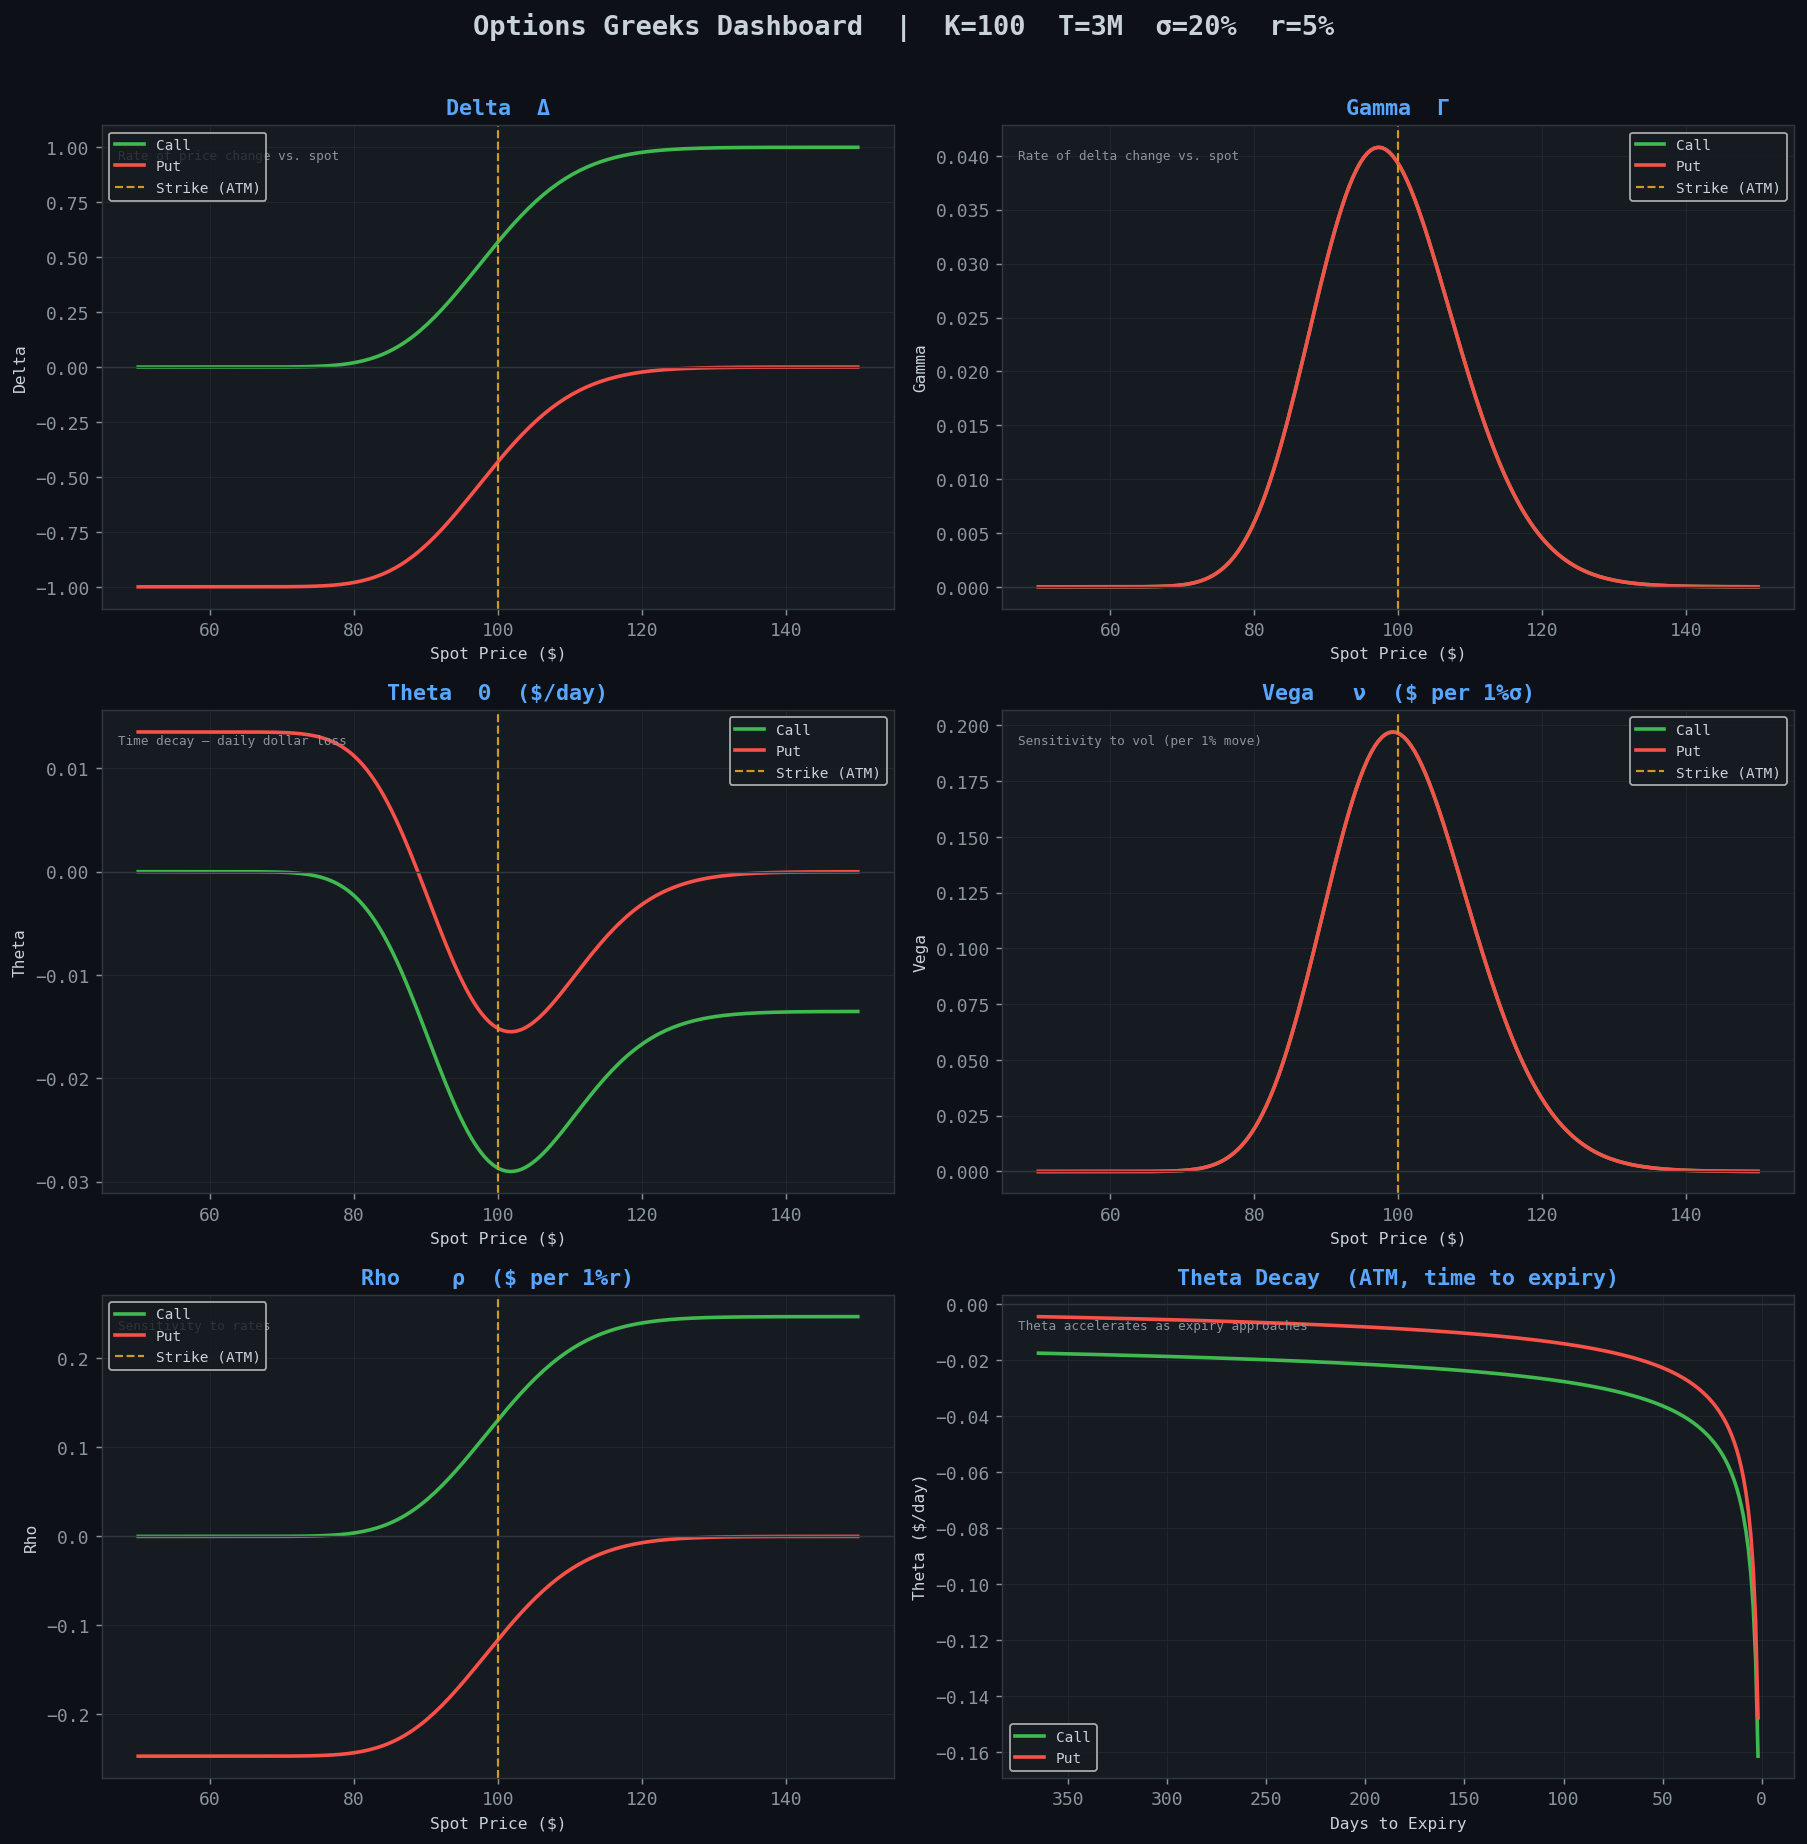

[SAVED] ../outputs/greeks_dashboard.png


In [22]:
# ============================================================
# CELL 5: GREEKS VISUALISATION DASHBOARD
# ============================================================

K_ref, T_ref, r_ref, sigma_ref = 100, 0.25, 0.05, 0.20

call_df = greeks_profile(K_ref, T_ref, r_ref, sigma_ref, "call")
put_df  = greeks_profile(K_ref, T_ref, r_ref, sigma_ref, "put")

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(
    "Options Greeks Dashboard  |  K=100  T=3M  σ=20%  r=5%",
    fontsize=15, fontweight="bold", color="#c9d1d9", y=1.01
)

panels = [
    ("delta",  "Delta  Δ",              "Rate of price change vs. spot"),
    ("gamma",  "Gamma  Γ",              "Rate of delta change vs. spot"),
    ("theta",  "Theta  Θ  ($/day)",     "Time decay — daily dollar loss"),
    ("vega",   "Vega   ν  ($ per 1%σ)", "Sensitivity to vol (per 1% move)"),
    ("rho",    "Rho    ρ  ($ per 1%r)", "Sensitivity to rates"),
]

for ax, (col, title, desc) in zip(axes.flat, panels):
    ax.plot(call_df.index, call_df[col], color=GREEN,  lw=2, label="Call")
    ax.plot(put_df.index,  put_df[col],  color=RED,    lw=2, label="Put")
    ax.axvline(K_ref, color=ORANGE, lw=1.2, ls="--", label="Strike (ATM)")
    ax.axhline(0,     color="#30363d", lw=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold", color=ACCENT)
    ax.set_xlabel("Spot Price ($)", fontsize=9)
    ax.set_ylabel(col.capitalize(), fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.02, 0.95, desc, transform=ax.transAxes,
            fontsize=7, color="#8b949e", va="top")

# 6th panel: Theta decay over time for ATM option
ax_t = axes[2, 1]
T_range = np.linspace(0.005, 1.0, 300)
theta_call_t = [compute_greeks(100, 100, t, 0.05, 0.20, "call")["theta"]
                for t in T_range]
theta_put_t  = [compute_greeks(100, 100, t, 0.05, 0.20, "put")["theta"]
                for t in T_range]

ax_t.plot(T_range * 365, theta_call_t, color=GREEN, lw=2, label="Call")
ax_t.plot(T_range * 365, theta_put_t,  color=RED,   lw=2, label="Put")
ax_t.axhline(0, color="#30363d", lw=0.8)
ax_t.invert_xaxis()
ax_t.set_title("Theta Decay  (ATM, time to expiry)", fontsize=12,
               fontweight="bold", color=ACCENT)
ax_t.set_xlabel("Days to Expiry", fontsize=9)
ax_t.set_ylabel("Theta ($/day)", fontsize=9)
ax_t.legend(fontsize=8)
ax_t.text(0.02, 0.95, "Theta accelerates as expiry approaches",
          transform=ax_t.transAxes, fontsize=7, color="#8b949e", va="top")

plt.tight_layout()
plt.savefig("../outputs/greeks_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#0d1117")
plt.show()
print("[SAVED] ../outputs/greeks_dashboard.png")


In [23]:
# ============================================================
# CELL 6: FETCH LIVE OPTIONS CHAIN DATA
# ============================================================

def fetch_options_data(ticker_symbol: str) -> tuple[pd.DataFrame, pd.DataFrame,
                                                    float, float, list]:
    """
    Fetch live options chain for all available expirations.

    Returns
    -------
    calls_all  : DataFrame of all call options across expirations
    puts_all   : DataFrame of all put options across expirations
    spot_price : Current underlying price
    risk_free  : Approximated risk-free rate (10Y Treasury)
    expirations: List of expiry date strings
    """
    ticker     = yf.Ticker(ticker_symbol)
    spot_price = ticker.fast_info["lastPrice"]
    expirations = ticker.options

    # Proxy risk-free rate: fetch ^TNX (10Y Treasury yield)
    try:
        tnx        = yf.Ticker("^TNX")
        risk_free  = tnx.fast_info["lastPrice"] / 100
    except Exception:
        risk_free  = 0.045   # fallback

    calls_list, puts_list = [], []

    for expiry in expirations:
        try:
            chain = ticker.option_chain(expiry)
            expiry_dt = datetime.strptime(expiry, "%Y-%m-%d")
            T = max((expiry_dt - datetime.today()).days / 365, 1/365)

            for df, opt_type in [(chain.calls, "call"), (chain.puts, "put")]:
                df = df.copy()
                df["expiry"]      = expiry
                df["T"]           = round(T, 6)
                df["option_type"] = opt_type
                df["spot"]        = spot_price
                # Moneyness: ln(K/S)
                df["moneyness"]   = np.log(df["strike"] / spot_price)

                if opt_type == "call":
                    calls_list.append(df)
                else:
                    puts_list.append(df)
        except Exception as e:
            print(f"  [WARN] Skipping {expiry}: {e}")

    calls_all = pd.concat(calls_list, ignore_index=True)
    puts_all  = pd.concat(puts_list,  ignore_index=True)

    # Clean: drop zero-volume and extreme IVs
    for df in [calls_all, puts_all]:
        df.dropna(subset=["impliedVolatility"], inplace=True)
        df.query("impliedVolatility > 0.01 and impliedVolatility < 5.0",
                 inplace=True)
        df.query("lastPrice > 0", inplace=True)

    print(f"\n{'='*50}")
    print(f"  Ticker         : {ticker_symbol}")
    print(f"  Spot Price     : ${spot_price:.2f}")
    print(f"  Risk-Free Rate : {risk_free:.2%}")
    print(f"  Expirations    : {len(expirations)}")
    print(f"  Call contracts : {len(calls_all):,}")
    print(f"  Put contracts  : {len(puts_all):,}")
    print(f"{'='*50}")

    return calls_all, puts_all, spot_price, risk_free, list(expirations)


calls, puts, SPOT, RISK_FREE, EXPIRIES = fetch_options_data(TICKER)



  Ticker         : GE
  Spot Price     : $286.79
  Risk-Free Rate : 4.39%
  Expirations    : 13
  Call contracts : 489
  Put contracts  : 458


In [24]:
# ============================================================
# CELL 7: IMPLIED VOLATILITY — NEWTON-RAPHSON + BISECTION
# ============================================================

def implied_vol(market_price: float, S: float, K: float, T: float,
                r: float, option_type: str = "call", q: float = 0.0,
                max_iter: int = 200, tol: float = 1e-6) -> float:
    """
    Calculate implied volatility using Newton-Raphson with Bisection fallback.

    Strategy
    --------
    1. Newton-Raphson (fast convergence near the solution)
    2. If NR diverges or fails, fall back to Brentq bisection (robust)
    3. Return NaN if both fail (deep ITM/OTM, illiquid options)

    Parameters
    ----------
    market_price : Observed market price of the option
    max_iter     : Maximum NR iterations
    tol          : Convergence tolerance

    Returns
    -------
    Implied volatility (decimal) or np.nan
    """
    # Intrinsic value check
    intrinsic = (max(S - K, 0) if option_type == "call"
                 else max(K - S, 0))
    if market_price <= intrinsic + 1e-5 or T <= 0:
        return np.nan

    # ── Method 1: Newton-Raphson ──────────────────────────────
    # Brenner-Subrahmanyam ATM IV approximation as starting point
    sigma = np.sqrt(2 * np.pi / T) * (market_price / S)
    sigma = np.clip(sigma, 0.01, 3.0)

    for _ in range(max_iter):
        price_est = bs_price(S, K, T, r, sigma, option_type, q)
        vega_est  = (S * np.exp(-q * T) * norm.pdf(
                        _d1_d2(S, K, T, r, sigma, q)[0])
                     * np.sqrt(T))
        if vega_est < 1e-10:
            break
        diff  = price_est - market_price
        sigma -= diff / vega_est
        sigma  = np.clip(sigma, 1e-6, 10.0)
        if abs(diff) < tol:
            return sigma

    # ── Method 2: Brentq Bisection (fallback) ─────────────────
    try:
        objective = lambda s: bs_price(S, K, T, r, s, option_type, q) - market_price
        if objective(0.001) * objective(10.0) < 0:
            return brentq(objective, 0.001, 10.0, xtol=tol, maxiter=500)
    except Exception:
        pass

    return np.nan


def add_calc_iv(df: pd.DataFrame, r: float, q: float = 0.0) -> pd.DataFrame:
    """
    Add a 'calc_iv' column to an options DataFrame using our own IV engine.
    Uses mid-price (bid+ask)/2 where available, else lastPrice.
    """
    df = df.copy()
    has_bid_ask = ("bid" in df.columns and "ask" in df.columns
                   and df["bid"].notna().any())
    if has_bid_ask:
        df["mid_price"] = (df["bid"] + df["ask"]) / 2
        df["mid_price"] = np.where(df["mid_price"] <= 0,
                                   df["lastPrice"], df["mid_price"])
    else:
        df["mid_price"] = df["lastPrice"]

    df["calc_iv"] = df.apply(
        lambda row: implied_vol(
            row["mid_price"], row["spot"], row["strike"],
            row["T"], r, row["option_type"], q
        ), axis=1
    )
    return df


print("[INFO] Computing implied volatilities via Newton-Raphson + Bisection...")
print("[INFO] This may take 30–60 seconds for large option chains...\n")

calls = add_calc_iv(calls, RISK_FREE)
puts  = add_calc_iv(puts,  RISK_FREE)

# Validation: compare yfinance IV vs. our calculated IV
compare_df = calls[["strike", "expiry", "T", "impliedVolatility",
                     "calc_iv"]].dropna().copy()
compare_df["iv_diff"] = (compare_df["calc_iv"]
                         - compare_df["impliedVolatility"]).abs()

print(f"  IV comparison (yfinance vs. calculated):")
print(f"  Mean absolute difference : {compare_df['iv_diff'].mean():.4f}")
print(f"  Median abs. difference   : {compare_df['iv_diff'].median():.4f}")
print(f"  (Small differences expected due to bid-ask spread and rate proxy)")


[INFO] Computing implied volatilities via Newton-Raphson + Bisection...
[INFO] This may take 30–60 seconds for large option chains...

  IV comparison (yfinance vs. calculated):
  Mean absolute difference : 0.0722
  Median abs. difference   : 0.0501
  (Small differences expected due to bid-ask spread and rate proxy)


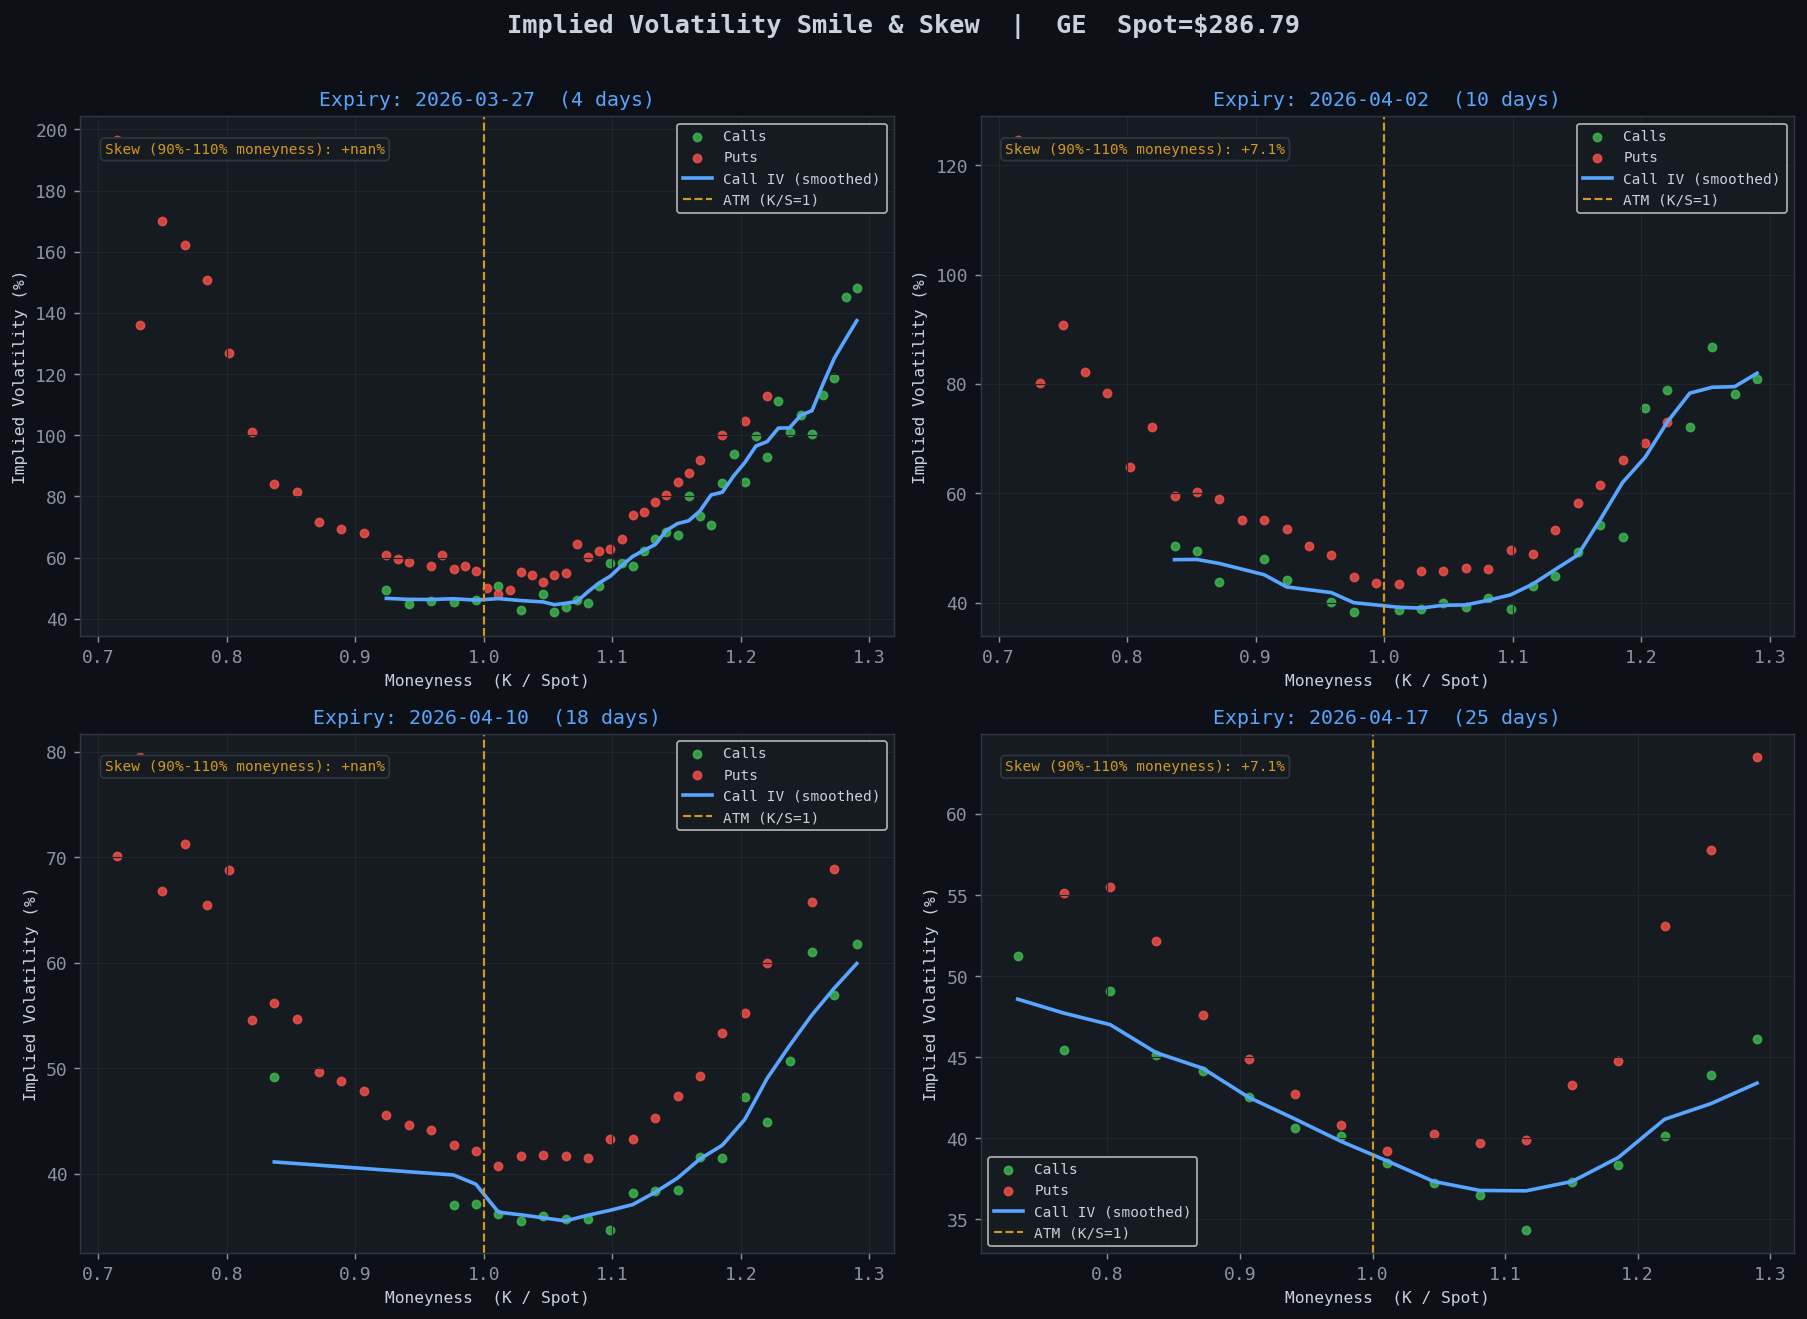

[SAVED] ../outputs/vol_smile.png


In [25]:
# ============================================================
# CELL 8: VOLATILITY SMILE & SKEW BY EXPIRY
# ============================================================

def plot_vol_smile(calls: pd.DataFrame, puts: pd.DataFrame,
                   spot: float, n_expiries: int = 4):
    """
    Plot the implied volatility smile for calls and puts
    across the nearest n_expiries expirations.
    """
    expiry_list = sorted(calls["expiry"].unique())[:n_expiries]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Implied Volatility Smile & Skew  |  {TICKER}  Spot=${spot:.2f}",
        fontsize=14, fontweight="bold", color="#c9d1d9", y=1.01
    )

    for ax, expiry in zip(axes.flat, expiry_list):
        c_exp = calls[calls["expiry"] == expiry].copy()
        p_exp = puts[puts["expiry"]  == expiry].copy()

        # Use moneyness (K/S) on x-axis for comparability
        c_exp["K_S"] = c_exp["strike"] / spot
        p_exp["K_S"] = p_exp["strike"] / spot

        # Filter to liquid strikes: 0.70 ≤ K/S ≤ 1.30
        c_exp = c_exp.query("0.70 <= K_S <= 1.30").dropna(subset=["calc_iv"])
        p_exp = p_exp.query("0.70 <= K_S <= 1.30").dropna(subset=["calc_iv"])

        ax.scatter(c_exp["K_S"], c_exp["calc_iv"] * 100,
                   color=GREEN,  alpha=0.8, s=20, label="Calls")
        ax.scatter(p_exp["K_S"], p_exp["calc_iv"] * 100,
                   color=RED,    alpha=0.8, s=20, label="Puts")

        # Smooth curve through call IVs
        if len(c_exp) > 5:
            c_sorted = c_exp.sort_values("K_S")
            ax.plot(c_sorted["K_S"],
                    c_sorted["calc_iv"].rolling(5, center=True,
                                                min_periods=1).mean() * 100,
                    color=ACCENT, lw=2, label="Call IV (smoothed)")

        ax.axvline(1.0, color=ORANGE, lw=1.2, ls="--", label="ATM (K/S=1)")

        T_days = c_exp["T"].mean() * 365 if len(c_exp) > 0 else 0
        ax.set_title(f"Expiry: {expiry}  ({T_days:.0f} days)",
                     fontsize=11, color=ACCENT)
        ax.set_xlabel("Moneyness  (K / Spot)", fontsize=9)
        ax.set_ylabel("Implied Volatility (%)", fontsize=9)
        ax.legend(fontsize=8)

        # Annotate skew: IV difference between 90% and 110% moneyness
        try:
            iv_90  = c_exp[c_exp["K_S"].between(0.88, 0.92)]["calc_iv"].mean()
            iv_110 = c_exp[c_exp["K_S"].between(1.08, 1.12)]["calc_iv"].mean()
            skew   = (iv_90 - iv_110) * 100
            ax.text(0.03, 0.95,
                    f"Skew (90%-110% moneyness): {skew:+.1f}%",
                    transform=ax.transAxes, fontsize=8,
                    color=ORANGE, va="top",
                    bbox=dict(boxstyle="round,pad=0.3",
                              fc="#161b22", ec="#30363d"))
        except Exception:
            pass

    plt.tight_layout()
    plt.savefig("../outputs/vol_smile.png", dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.show()
    print("[SAVED] ../outputs/vol_smile.png")


plot_vol_smile(calls, puts, SPOT)


In [26]:
# ============================================================
# CELL 9 (FIXED): 3D IMPLIED VOLATILITY SURFACE (PLOTLY)
# ============================================================

import subprocess, sys

def ensure_kaleido():
    """Install kaleido silently if not present."""
    try:
        import kaleido
        return True
    except ImportError:
        print("[INFO] kaleido not found — installing...")
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-U", "kaleido", "-q"],
            capture_output=True, text=True
        )
        try:
            import kaleido
            print("[INFO] kaleido installed successfully.")
            return True
        except ImportError:
            print("[WARN] kaleido install failed. PNG export will be skipped.")
            print("       Run manually:  pip install -U kaleido")
            return False


def build_vol_surface(calls: pd.DataFrame, spot: float,
                      max_T: float = 1.5) -> pd.DataFrame:
    """
    Build a clean volatility surface from call options data.
    Aggregates IV by (moneyness bucket, expiry) for a smooth surface.
    """
    df = calls[calls["T"] <= max_T].dropna(subset=["calc_iv"]).copy()
    df = df[df["calc_iv"].between(0.01, 2.0)]

    df["mono_bucket"] = pd.cut(
        df["strike"] / spot,
        bins=np.arange(0.70, 1.325, 0.025),
        labels=np.round(np.arange(0.7125, 1.30, 0.025), 4)
    ).astype(float)

    df["T_bucket"] = df["expiry"]

    surface = (df.groupby(["mono_bucket", "T_bucket"])["calc_iv"]
               .median()
               .unstack("T_bucket"))

    surface = surface.ffill(axis=1).bfill(axis=1)
    surface = surface.ffill(axis=0).bfill(axis=0)
    return surface


def save_plotly_fig(fig, html_path: str, png_path: str):
    """
    Save a Plotly figure.
    - HTML always saved (no dependencies).
    - PNG saved only if kaleido is available; falls back to
      a matplotlib screenshot of the HTML if kaleido fails.
    """
    # ── Always save interactive HTML ─────────────────────────
    fig.write_html(html_path)
    print(f"[SAVED] {html_path}  (interactive — open in browser)")

    # ── Attempt PNG via kaleido ───────────────────────────────
    kaleido_ok = ensure_kaleido()
    if kaleido_ok:
        try:
            fig.write_image(png_path, scale=2, engine="kaleido")
            print(f"[SAVED] {png_path}  (static PNG)")
            return
        except Exception as e:
            print(f"[WARN] kaleido write_image failed: {e}")

    # ── Fallback: export surface as matplotlib 3D plot ────────
    print("[INFO] Falling back to matplotlib 3D surface for PNG export...")
    _save_surface_matplotlib(fig, png_path)


def _save_surface_matplotlib(plotly_fig, png_path: str):
    """
    Reconstruct the vol surface as a matplotlib 3D plot.
    Called only when kaleido is unavailable.
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    # Extract surface data from the Plotly figure
    surface_trace = None
    for trace in plotly_fig.data:
        if hasattr(trace, "z") and trace.z is not None:
            surface_trace = trace
            break

    if surface_trace is None:
        print("[WARN] No surface trace found. PNG export skipped.")
        return

    X = np.array(surface_trace.x, dtype=float)   # Days to expiry
    Y = np.array(surface_trace.y, dtype=float)   # Moneyness
    Z = np.array(surface_trace.z, dtype=float)   # IV %

    XX, YY = np.meshgrid(X, Y)

    fig_mpl = plt.figure(figsize=(12, 8), facecolor="#0d1117")
    ax = fig_mpl.add_subplot(111, projection="3d",
                             facecolor="#161b22")

    surf = ax.plot_surface(
        XX, YY, Z,
        cmap="plasma",
        alpha=0.90,
        linewidth=0,
        antialiased=True
    )

    # ATM line
    atm_z = np.interp(1.0, Y, Z.mean(axis=1))
    ax.plot(X, [1.0] * len(X),
            [np.interp(1.0, Y, Z[:, i]) for i in range(len(X))],
            color="yellow", lw=2.5, zorder=5, label="ATM (K/S=1)")

    cbar = fig_mpl.colorbar(surf, ax=ax, shrink=0.5, pad=0.08)
    cbar.set_label("Implied Vol (%)", color="#c9d1d9")
    cbar.ax.yaxis.set_tick_params(color="#c9d1d9")
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#c9d1d9")

    ax.set_xlabel("Days to Expiry",    color="#c9d1d9", labelpad=8)
    ax.set_ylabel("Moneyness (K/S)",   color="#c9d1d9", labelpad=8)
    ax.set_zlabel("Implied Vol (%)",   color="#c9d1d9", labelpad=8)
    ax.tick_params(colors="#8b949e")
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor("#30363d")
    ax.yaxis.pane.set_edgecolor("#30363d")
    ax.zaxis.pane.set_edgecolor("#30363d")

    ax.set_title(
        f"Implied Volatility Surface — {TICKER}\n"
        f"Spot: ${SPOT:.2f}  |  Risk-Free: {RISK_FREE:.2%}",
        color="#c9d1d9", fontsize=13, pad=15
    )
    ax.legend(fontsize=9, loc="upper left",
              facecolor="#161b22", labelcolor="#c9d1d9")

    plt.tight_layout()
    plt.savefig(png_path, dpi=150, bbox_inches="tight",
                facecolor="#0d1117")
    plt.close()
    print(f"[SAVED] {png_path}  (matplotlib fallback PNG)")


def plot_vol_surface_3d(calls: pd.DataFrame, spot: float, risk_free: float):
    """
    Render an interactive 3D Implied Volatility Surface using Plotly.
    Saves both interactive HTML and static PNG with kaleido fallback.
    """
    surface = build_vol_surface(calls, spot)

    if surface.empty:
        print("[WARN] Surface data is empty. Check that calc_iv was computed.")
        return

    X_labels = surface.columns.tolist()       # expiry date strings
    Y_labels = surface.index.tolist()         # moneyness values
    Z        = surface.values * 100           # IV in %

    T_days = [(datetime.strptime(e, "%Y-%m-%d") - datetime.today()).days
               for e in X_labels]
    X_num  = np.array(T_days,   dtype=float)
    Y_num  = np.array(Y_labels, dtype=float)

    fig = go.Figure(data=[go.Surface(
        x=X_num,
        y=Y_num,
        z=Z,
        colorscale="Plasma",
        opacity=0.92,
        colorbar=dict(
            title="IV (%)",
            titlefont=dict(color="white"),
            tickfont=dict(color="white")
        ),
        contours={
            "z": {"show": True, "usecolormap": True,
                  "highlightcolor": "white", "project_z": False}
        }
    )])

    # ATM line overlay
    atm_z_vals = [float(np.interp(1.0, Y_num, Z[:, i]))
                  for i in range(len(X_num))]
    fig.add_trace(go.Scatter3d(
        x=X_num,
        y=[1.0] * len(X_num),
        z=atm_z_vals,
        mode="lines",
        line=dict(color="yellow", width=4),
        name="ATM Line (K/S = 1)"
    ))

    fig.update_layout(
        title=dict(
            text=(f"<b>Implied Volatility Surface — {TICKER}</b>"
                  f"<br><sup>Spot: ${spot:.2f}  |  "
                  f"Risk-Free: {risk_free:.2%}  |  "
                  f"Source: Yahoo Finance</sup>"),
            x=0.5, font=dict(color="white", size=16)
        ),
        scene=dict(
            xaxis=dict(title="Days to Expiry",
                       titlefont=dict(color="white"),
                       tickfont=dict(color="white"),
                       backgroundcolor="#161b22",
                       gridcolor="#30363d"),
            yaxis=dict(title="Moneyness (K/S)",
                       titlefont=dict(color="white"),
                       tickfont=dict(color="white"),
                       backgroundcolor="#161b22",
                       gridcolor="#30363d"),
            zaxis=dict(title="Implied Vol (%)",
                       titlefont=dict(color="white"),
                       tickfont=dict(color="white"),
                       backgroundcolor="#161b22",
                       gridcolor="#30363d"),
            bgcolor="#0d1117",
        ),
        paper_bgcolor="#0d1117",
        font=dict(color="white"),
        width=900, height=650,
        margin=dict(l=40, r=40, t=80, b=40)
    )

    save_plotly_fig(
        fig,
        html_path="../outputs/vol_surface.html",
        png_path="../outputs/vol_surface.png"
    )


# ── Run ───────────────────────────────────────────────────────
plot_vol_surface_3d(calls, SPOT, RISK_FREE)


[SAVED] ../outputs/vol_surface.html  (interactive — open in browser)
[WARN] kaleido write_image failed: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido

[INFO] Falling back to matplotlib 3D surface for PNG export...
[SAVED] ../outputs/vol_surface.png  (matplotlib fallback PNG)


In [27]:
# ============================================================
# CELL 10 (FIXED): DELTA HEDGING SIMULATION
# ============================================================

def fetch_price_series(ticker_symbol: str, period: str = "1y") -> pd.Series:
    """
    Robustly fetch a 1D closing price Series from yfinance.
    Handles both flat and MultiIndex column structures (yfinance v0.2+).
    """
    raw = yf.download(ticker_symbol, period=period,
                      interval="1d", auto_adjust=True, progress=False)

    # yfinance >= 0.2 returns MultiIndex columns: (field, ticker)
    if isinstance(raw.columns, pd.MultiIndex):
        close = raw["Close"][ticker_symbol]
    else:
        close = raw["Close"]

    # Flatten to 1D — defensive squeeze in case shape is (n, 1)
    close = close.squeeze()

    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    return close.dropna().astype(float)


def simulate_delta_hedge(ticker_symbol: str, K: float, T_init: float,
                         r: float, sigma_assumed: float,
                         n_shares: int = 100,
                         hedge_freq_days: int = 1) -> pd.DataFrame:
    """
    Simulate a delta-neutral hedging strategy for a short call position.

    The dealer sells a call option and dynamically delta-hedges by holding
    delta × n_shares of the underlying stock. Cumulative P&L tracks the
    cost of maintaining the hedge vs. the premium received.

    Parameters
    ----------
    ticker_symbol  : Underlying equity ticker (e.g. 'AAPL')
    K              : Strike price — use near ATM for meaningful results
    T_init         : Initial time to expiry in years (e.g. 0.5 = 6 months)
    r              : Risk-free rate (decimal)
    sigma_assumed  : Model volatility used for hedging (decimal)
    n_shares       : Number of shares the option covers (1 contract = 100)
    hedge_freq_days: Rebalance every N trading days (1 = daily)
    """

    # ── 1. Fetch and prepare price data ──────────────────────
    prices_series = fetch_price_series(ticker_symbol, period="1y")
    prices_series.index = pd.to_datetime(prices_series.index)

    n_days   = int(T_init * 252)
    prices   = prices_series.values[-n_days:] if len(prices_series) >= n_days \
               else prices_series.values
    dates    = prices_series.index[-len(prices):]
    n_steps  = len(prices)

    # Ensure prices is strictly 1D float array
    prices = np.array(prices, dtype=float).flatten()

    # ── 2. Realised volatility from historical data ───────────
    log_rets     = np.diff(np.log(prices))
    sigma_actual = float(np.std(log_rets) * np.sqrt(252))

    # ── 3. Initialise portfolio ───────────────────────────────
    S0          = float(prices[0])
    T_curr      = float(T_init)
    position    = 0.0   # shares held as hedge
    cash        = 0.0   # running cash account

    initial_prem = bs_price(S0, K, T_curr, r, sigma_assumed, "call") * n_shares
    cash        += initial_prem   # dealer receives option premium upfront

    records = []

    # ── 4. Step through each trading day ─────────────────────
    for i in range(n_steps):
        S      = float(prices[i])         # scalar float — no array issues
        T_curr = max((n_steps - i) / 252, 1e-4)
        date   = dates[i]

        # New delta target
        g           = compute_greeks(S, K, T_curr, r, sigma_assumed, "call")
        new_delta   = float(g["delta"]) if not np.isnan(g["delta"]) else position / n_shares
        target_pos  = new_delta * n_shares

        # Rebalance on schedule
        if i % hedge_freq_days == 0:
            trade   = target_pos - position
            cash   -= trade * S         # buy positive / sell negative
            position = target_pos

        # Mark-to-market: short call = negative value to the dealer
        option_mtm = -bs_price(S, K, T_curr, r, sigma_assumed, "call") * n_shares

        # Total portfolio value = cash + stock position + short option MTM
        portfolio_value = cash + position * S + option_mtm

        # Hedge P&L = how much of the initial premium is left after hedging costs
        hedge_pnl = initial_prem + portfolio_value

        records.append({
            "date":            date,
            "spot":            round(S, 4),
            "T_remaining":     round(T_curr, 4),
            "delta":           round(new_delta, 4),
            "position_shares": round(position, 2),
            "cash":            round(cash, 2),
            "option_mtm":      round(option_mtm, 2),
            "portfolio_value": round(portfolio_value, 2),
            "hedge_pnl":       round(hedge_pnl, 2),
        })

    df = pd.DataFrame(records)
    df["sigma_assumed"] = sigma_assumed
    df["sigma_actual"]  = round(sigma_actual, 4)
    df["initial_prem"]  = round(initial_prem, 2)

    # ── 5. Summary ────────────────────────────────────────────
    print(f"\n{'='*52}")
    print(f"  Delta Hedge Simulation  —  {ticker_symbol}")
    print(f"  Strike (K)          : ${K:.2f}")
    print(f"  Initial Spot (S0)   : ${S0:.2f}")
    print(f"  Moneyness (S0/K)    : {S0/K:.3f}")
    print(f"  Assumed σ (model)   : {sigma_assumed:.1%}")
    print(f"  Realised σ (hist.)  : {sigma_actual:.1%}")
    print(f"  Vol difference      : {(sigma_actual - sigma_assumed)*100:+.1f}%")
    print(f"  Rebalance frequency : every {hedge_freq_days} day(s)")
    print(f"  Steps simulated     : {n_steps}")
    print(f"  Initial Premium     : ${initial_prem:.2f}")
    print(f"  Final Hedge P&L     : ${df['hedge_pnl'].iloc[-1]:.2f}")
    print(f"{'='*52}")

    return df


# ── Run simulation ────────────────────────────────────────────
near_atm_K = round(SPOT / 5) * 5   # round spot to nearest $5

hedge_df = simulate_delta_hedge(
    ticker_symbol   = TICKER,
    K               = near_atm_K,
    T_init          = 0.50,          # 6-month option
    r               = RISK_FREE,
    sigma_assumed   = 0.25,          # 25% assumed vol
    n_shares        = 100,
    hedge_freq_days = 1              # daily rebalancing
)

hedge_df.to_csv("../outputs/delta_hedge_simulation.csv", index=False)
print("[SAVED] ../outputs/delta_hedge_simulation.csv")



  Delta Hedge Simulation  —  GE
  Strike (K)          : $285.00
  Initial Spot (S0)   : $299.99
  Moneyness (S0/K)    : 1.053
  Assumed σ (model)   : 25.0%
  Realised σ (hist.)  : 30.0%
  Vol difference      : +5.0%
  Rebalance frequency : every 1 day(s)
  Steps simulated     : 126
  Initial Premium     : $3269.20
  Final Hedge P&L     : $3372.68
[SAVED] ../outputs/delta_hedge_simulation.csv


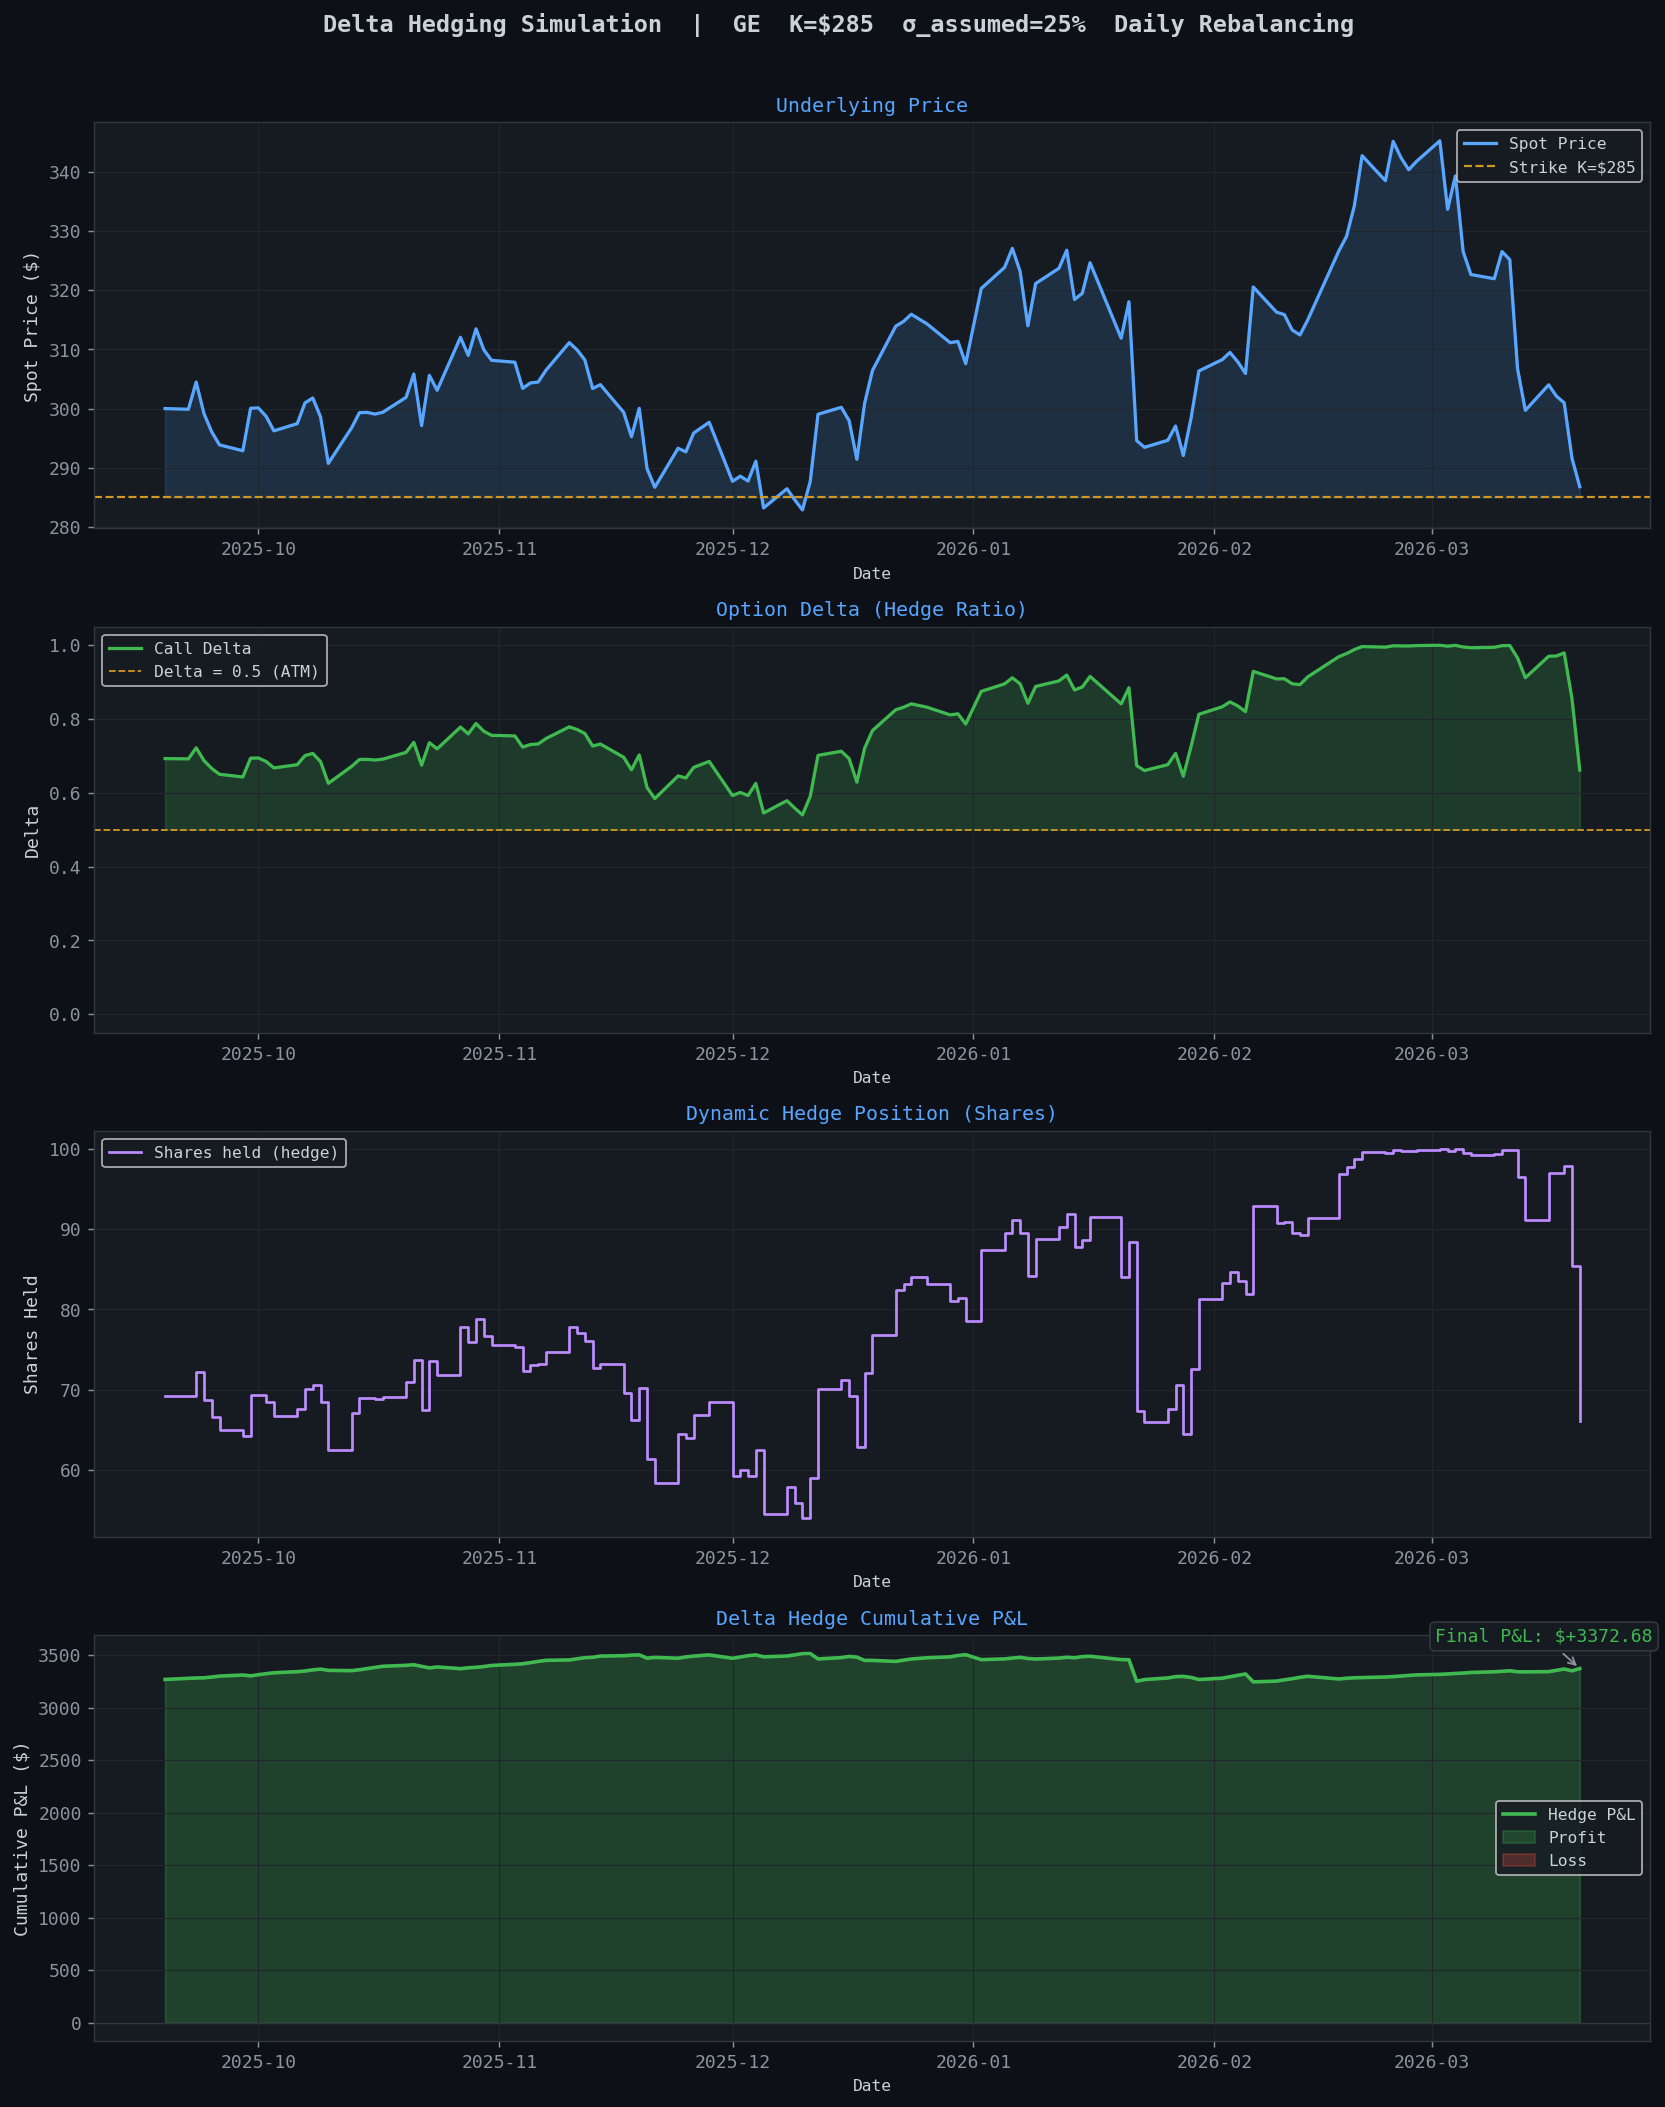

[SAVED] ../outputs/delta_hedge_simulation.png


In [28]:
# ============================================================
# CELL 11: DELTA HEDGE VISUALISATION (4-PANEL)
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=False)
fig.suptitle(
    f"Delta Hedging Simulation  |  {TICKER}  K=${near_atm_K}  "
    f"σ_assumed=25%  Daily Rebalancing",
    fontsize=13, fontweight="bold", color="#c9d1d9", y=1.01
)

# Panel 1: Spot price over time
axes[0].plot(hedge_df["date"], hedge_df["spot"],
             color=ACCENT, lw=1.8, label="Spot Price")
axes[0].axhline(near_atm_K, color=ORANGE, lw=1.2,
                ls="--", label=f"Strike K=${near_atm_K}")
axes[0].fill_between(hedge_df["date"], hedge_df["spot"],
                     near_atm_K, alpha=0.15, color=ACCENT)
axes[0].set_ylabel("Spot Price ($)", fontsize=10)
axes[0].set_title("Underlying Price", fontsize=11, color=ACCENT)
axes[0].legend(fontsize=9)

# Panel 2: Delta over time
axes[1].plot(hedge_df["date"], hedge_df["delta"],
             color=GREEN, lw=1.8, label="Call Delta")
axes[1].axhline(0.5, color=ORANGE, lw=1.0, ls="--", label="Delta = 0.5 (ATM)")
axes[1].fill_between(hedge_df["date"], hedge_df["delta"], 0.5,
                     alpha=0.2, color=GREEN)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_ylabel("Delta", fontsize=10)
axes[1].set_title("Option Delta (Hedge Ratio)", fontsize=11, color=ACCENT)
axes[1].legend(fontsize=9)

# Panel 3: Hedge shares held
axes[2].step(hedge_df["date"], hedge_df["position_shares"],
             color=PURPLE, lw=1.5, where="post", label="Shares held (hedge)")
axes[2].set_ylabel("Shares Held", fontsize=10)
axes[2].set_title("Dynamic Hedge Position (Shares)", fontsize=11, color=ACCENT)
axes[2].legend(fontsize=9)

# Panel 4: Cumulative hedge P&L
pnl = hedge_df["hedge_pnl"]
axes[3].plot(hedge_df["date"], pnl, color=GREEN, lw=2, label="Hedge P&L")
axes[3].fill_between(hedge_df["date"], pnl, 0,
                     where=(pnl >= 0), alpha=0.25, color=GREEN, label="Profit")
axes[3].fill_between(hedge_df["date"], pnl, 0,
                     where=(pnl < 0),  alpha=0.25, color=RED,   label="Loss")
axes[3].axhline(0, color="#30363d", lw=0.8)

final_pnl = pnl.iloc[-1]
axes[3].annotate(
    f"Final P&L: ${final_pnl:+.2f}",
    xy=(hedge_df["date"].iloc[-1], final_pnl),
    xytext=(-80, 15), textcoords="offset points",
    fontsize=10, color=GREEN if final_pnl >= 0 else RED,
    arrowprops=dict(arrowstyle="->", color="#8b949e"),
    bbox=dict(boxstyle="round,pad=0.3", fc="#161b22", ec="#30363d")
)

axes[3].set_ylabel("Cumulative P&L ($)", fontsize=10)
axes[3].set_title("Delta Hedge Cumulative P&L", fontsize=11, color=ACCENT)
axes[3].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("Date", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/delta_hedge_simulation.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("[SAVED] ../outputs/delta_hedge_simulation.png")


In [29]:
# ============================================================
# CELL 12: OPTIONS CHAIN SUMMARY REPORT (STYLED DATAFRAME)
# ============================================================

def build_chain_report(calls: pd.DataFrame, puts: pd.DataFrame,
                       spot: float, n_expiries: int = 3) -> pd.DataFrame:
    """
    Build a summary report showing IV term structure and
    ATM Greeks for the nearest expirations.
    """
    rows = []
    expiry_list = sorted(calls["expiry"].unique())[:n_expiries]

    for expiry in expiry_list:
        c = calls[calls["expiry"] == expiry].copy()
        p = puts[puts["expiry"]  == expiry].copy()

        T = c["T"].mean() if len(c) > 0 else 0

        # ATM: closest strike to spot
        if len(c) > 0:
            atm_idx   = (c["strike"] - spot).abs().idxmin()
            atm_row   = c.loc[atm_idx]
            atm_K     = atm_row["strike"]
            atm_iv_c  = atm_row.get("calc_iv", np.nan)
            atm_price = atm_row.get("mid_price", atm_row.get("lastPrice", np.nan))
            greeks    = compute_greeks(spot, atm_K, T, RISK_FREE,
                                       atm_iv_c if not np.isnan(atm_iv_c) else 0.25,
                                       "call")
        else:
            atm_K = np.nan; atm_iv_c = np.nan
            atm_price = np.nan; greeks = {}

        # Put IV at same strike
        if len(p) > 0:
            atm_put = (p["strike"] - spot).abs().idxmin()
            atm_iv_p = p.loc[atm_put].get("calc_iv", np.nan)
        else:
            atm_iv_p = np.nan

        # IV skew: 25-delta put IV − 25-delta call IV (approx: OTM put vs OTM call)
        try:
            otm_put_iv  = p[p["strike"] < spot * 0.95]["calc_iv"].mean()
            otm_call_iv = c[c["strike"] > spot * 1.05]["calc_iv"].mean()
            skew = (otm_put_iv - otm_call_iv) * 100
        except Exception:
            skew = np.nan

        rows.append({
            "Expiry":           expiry,
            "Days to Expiry":   round(T * 365),
            "ATM Strike":       atm_K,
            "ATM Call IV (%)":  round(atm_iv_c * 100, 2) if not np.isnan(atm_iv_c) else np.nan,
            "ATM Put IV (%)":   round(atm_iv_p * 100, 2) if not np.isnan(atm_iv_p) else np.nan,
            "IV Skew (put-call %)": round(skew, 2) if not np.isnan(skew) else np.nan,
            "Call Price ($)":   round(atm_price, 2) if not np.isnan(atm_price) else np.nan,
            "Delta":            greeks.get("delta", np.nan),
            "Gamma":            greeks.get("gamma", np.nan),
            "Theta ($/day)":    greeks.get("theta", np.nan),
            "Vega ($ per 1%)":  greeks.get("vega",  np.nan),
        })

    report = pd.DataFrame(rows)
    report.to_csv("options_chain_report.csv", index=False)
    print("[SAVED] ../outputs/options_chain_report.csv\n")
    return report


report = build_chain_report(calls, puts, SPOT)

# Display styled
try:
    styled = (report.style
              .set_caption(f"Options Chain Report — {TICKER}  "
                           f"Spot=${SPOT:.2f}")
              .format(na_rep="—", precision=4)
              .background_gradient(subset=["ATM Call IV (%)",
                                           "ATM Put IV (%)"],
                                   cmap="RdYlGn_r")
              .set_properties(**{"text-align": "center"}))
    display(styled)
except Exception:
    print(report.to_string(index=False))


[SAVED] ../outputs/options_chain_report.csv

    Expiry  Days to Expiry  ATM Strike  ATM Call IV (%)  ATM Put IV (%)  IV Skew (put-call %)  Call Price ($)    Delta    Gamma  Theta ($/day)  Vega ($ per 1%)
2026-03-27               4       285.0            46.15           50.13                 58.45            6.52 0.565026 0.028413      -0.700380         0.118179
2026-04-02              10       290.0            38.58           43.59                 21.28            6.00 0.450850 0.021616      -0.377408         0.187937
2026-04-10              18       285.0            37.15           42.15                  4.70           10.65 0.557006 0.016687      -0.277480         0.251478


## Key Findings & Interpretation

### Volatility Surface Observations
- The IV surface is **not flat** — confirming Black-Scholes' key limitation
- **Volatility smile**: OTM options carry higher IV than ATM, reflecting tail-risk demand
- **Volatility skew**: Put IV > Call IV (especially for short maturities) — markets price  
  downside protection at a premium ("fear premium")
- **Term structure**: IV typically rises with expiry for stable markets; inverts near events

### Delta Hedging P&L Interpretation
- A **short call delta-hedged to zero** earns the option premium if realised vol < implied vol
- **P&L ≈ 0.5 × Gamma × (σ_realised² − σ_implied²) × S² × dt** per rebalancing step  
  (the "Gamma P&L" identity from dynamic hedging theory)
- Frequent rebalancing reduces hedging error but increases transaction costs

### Recruiter Take-Away
This project demonstrates: derivative pricing theory, Greeks for hedging, numerical  
methods (Newton-Raphson), real data engineering (yfinance), 3D surface visualisation,  
and a core derivatives trading concept (dynamic hedging). All with free data only.
